In [30]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timezone

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 60)

LOG_DIR = os.path.join("..", "datasets", "usage_logs")

VIEW_ORDER  = ["tableView", "chartView", "similarityView", "timeView"]
VIEW_LABELS = {
    "tableView":       "Tabular Overview",
    "chartView":       "Distribution Charts",
    "similarityView":  "Study Similarity",
    "timeView":        "Study Timeline",
}

In [31]:
log_files = sorted(glob.glob(os.path.join(LOG_DIR, "*.json")))
logs = []
for f in log_files:
    with open(f, encoding="utf-8") as fp:
        logs.append(json.load(fp))

print(f"Loaded {len(logs)} log(s):")
for lg in logs:
    print(f"  [{lg['participant_id']}]  {lg['total_events']} events  "
          f"{lg['recorded_from']} → {lg['recorded_to']}")

Loaded 7 log(s):
  [12]  243 events  2026-06-19T13:13:27.808Z → 2026-06-19T13:51:49.660Z
  [P21]  112 events  2026-06-15T09:50:32.605Z → 2026-06-15T10:37:47.231Z
  [P33]  186 events  2026-06-10T09:12:26.082Z → 2026-06-10T09:40:21.855Z
  [45]  326 events  2026-06-12T11:48:35.749Z → 2026-06-12T12:43:02.031Z
  [54]  258 events  2026-06-19T16:11:21.702Z → 2026-06-19T16:37:48.397Z
  [P68]  383 events  2026-06-09T09:23:03.441Z → 2026-06-09T10:07:42.136Z
  [97]  243 events  2026-06-08T11:25:04.855Z → 2026-06-08T12:05:56.166Z


## 1 · Session Overview

In [32]:
rows = []
for lg in logs:
    start = datetime.fromisoformat(lg["recorded_from"].replace("Z", "+00:00"))
    end   = datetime.fromisoformat(lg["recorded_to"].replace("Z", "+00:00"))
    dur_s = (end - start).total_seconds()
    rows.append({
        "Participant":    lg["participant_id"],
        "Start (UTC)":   lg["recorded_from"],
        "End (UTC)":     lg["recorded_to"],
        "Duration (min)": round(dur_s / 60, 2),
        "Total Events":  lg["total_events"],
    })

overview_df = pd.DataFrame(rows)
display(overview_df.style.hide(axis="index"))

Participant,Start (UTC),End (UTC),Duration (min),Total Events
12,2026-06-19T13:13:27.808Z,2026-06-19T13:51:49.660Z,38.360000,243
P21,2026-06-15T09:50:32.605Z,2026-06-15T10:37:47.231Z,47.240000,112
P33,2026-06-10T09:12:26.082Z,2026-06-10T09:40:21.855Z,27.930000,186
45,2026-06-12T11:48:35.749Z,2026-06-12T12:43:02.031Z,54.440000,326
54,2026-06-19T16:11:21.702Z,2026-06-19T16:37:48.397Z,26.440000,258
P68,2026-06-09T09:23:03.441Z,2026-06-09T10:07:42.136Z,44.640000,383
97,2026-06-08T11:25:04.855Z,2026-06-08T12:05:56.166Z,40.860000,243


## 2 · Total Recording Time

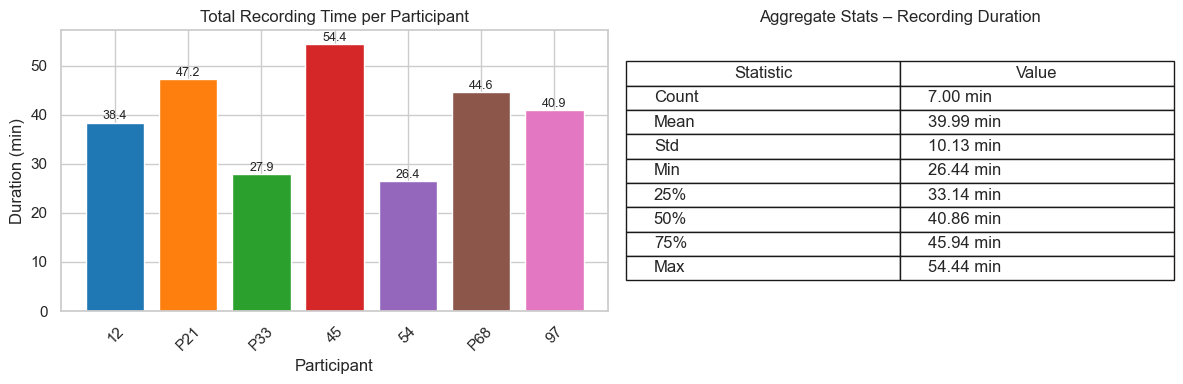

Total study time across all participants: 279.91 min (4.67 h)


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Per-participant bar ──────────────────────────────────────────────────────
ax = axes[0]
ax.bar(overview_df["Participant"], overview_df["Duration (min)"], color=sns.color_palette("tab10"))
ax.set_title("Total Recording Time per Participant")
ax.set_ylabel("Duration (min)")
ax.set_xlabel("Participant")
ax.tick_params(axis="x", rotation=45)
for i, (_, row) in enumerate(overview_df.iterrows()):
    ax.text(i, row["Duration (min)"] + 0.05, f"{row['Duration (min)']:.1f}", ha="center", va="bottom", fontsize=9)

# ── Aggregate stats table ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis("off")
stats = overview_df["Duration (min)"].describe().round(2)
stats_rows = [[k.capitalize(), f"{v:.2f} min"] for k, v in stats.items()]
tbl = ax2.table(cellText=stats_rows, colLabels=["Statistic", "Value"],
                loc="center", cellLoc="left")
tbl.scale(1, 1.6)
ax2.set_title("Aggregate Stats – Recording Duration")

plt.tight_layout()
plt.show()

print(f"Total study time across all participants: "
      f"{overview_df['Duration (min)'].sum():.2f} min "
      f"({overview_df['Duration (min)'].sum()/60:.2f} h)")

## 3 · Time Spent per View

Time is extracted from `page_unload.duration_ms` (time between the matching
`page_load` and `page_unload` events). The **last view** of each session
(no `page_unload` fired before `session_end`) is computed from
`session_end.ts − last_page_load.ts`.

In [34]:
def compute_view_times(lg):
    """Returns {view: total_ms} for one participant log."""
    times = {v: 0 for v in VIEW_ORDER}
    events = lg["events"]
    session_end_ts = next(
        (e["ts"] for e in reversed(events) if e["type"] == "session_end"), None
    )

    # Accumulate durations from page_unload events (duration_ms = load→unload gap)
    for e in events:
        if e["type"] == "page_unload" and e["view"] in times:
            times[e["view"]] += e.get("duration_ms", 0)

    # Handle the last view (no page_unload before session_end / tab close)
    if session_end_ts:
        unload_ts_by_view = {}
        last_load_ts_by_view = {}
        for e in events:
            if e["type"] == "page_load":
                last_load_ts_by_view[e["view"]] = e["ts"]
            elif e["type"] == "page_unload":
                unload_ts_by_view[e["view"]] = e["ts"]

        for view, load_ts in last_load_ts_by_view.items():
            # If this page_load happened AFTER the last page_unload for that view → still open
            unload_ts = unload_ts_by_view.get(view, 0)
            if load_ts > unload_ts:
                times[view] += session_end_ts - load_ts

    return times


# ── Build per-participant view-time DataFrame (seconds) ─────────────────────
view_rows = []
for lg in logs:
    vt = compute_view_times(lg)
    row = {"Participant": lg["participant_id"]}
    for v in VIEW_ORDER:
        row[VIEW_LABELS[v]] = round(vt[v] / 1000, 1)
    view_rows.append(row)

view_df = pd.DataFrame(view_rows).set_index("Participant")
display(view_df.style.format("{:.1f} s"))

,Tabular Overview,Distribution Charts,Study Similarity,Study Timeline
Participant,,,,
12,1804.8 s,94.0 s,165.8 s,225.3 s
P21,1725.9 s,5.7 s,1038.0 s,0.0 s
P33,1519.1 s,26.0 s,102.1 s,12.9 s
45,2778.9 s,88.3 s,85.3 s,311.9 s
54,1298.9 s,9.7 s,184.7 s,85.3 s
P68,1107.4 s,18.7 s,393.3 s,1131.2 s
97,2007.8 s,160.4 s,125.1 s,137.4 s


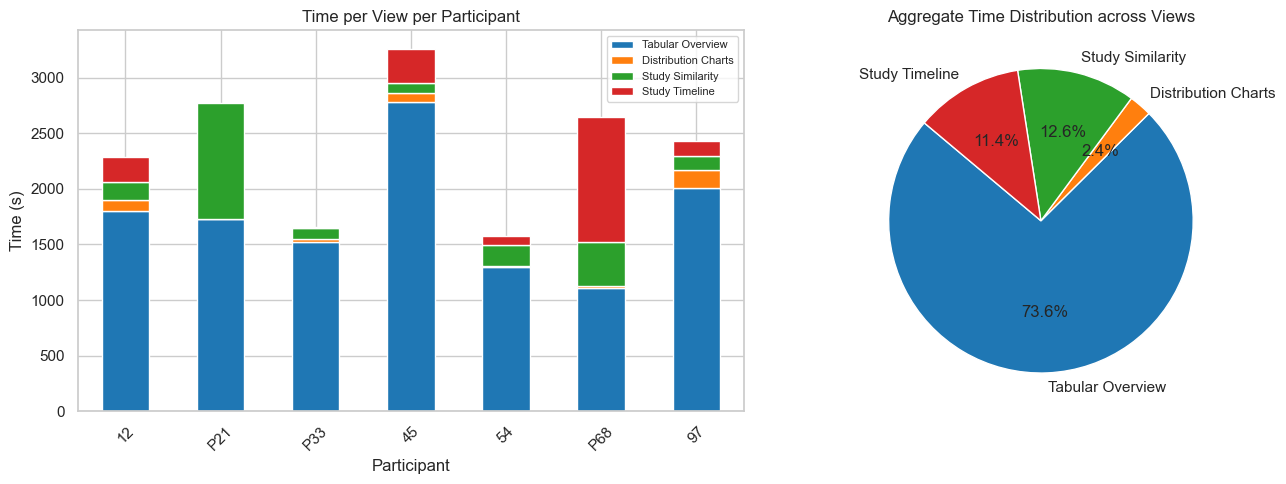

,Tabular Overview (%),Distribution Charts (%),Study Similarity (%),Study Timeline (%)
Participant,,,,
12,78.8 %,4.1 %,7.2 %,9.8 %
P21,62.3 %,0.2 %,37.5 %,0.0 %
P33,91.5 %,1.6 %,6.2 %,0.8 %
45,85.1 %,2.7 %,2.6 %,9.6 %
54,82.3 %,0.6 %,11.7 %,5.4 %
P68,41.8 %,0.7 %,14.8 %,42.7 %
97,82.6 %,6.6 %,5.1 %,5.7 %


In [35]:
palette = sns.color_palette("tab10", len(VIEW_ORDER))
view_col_map = dict(zip([VIEW_LABELS[v] for v in VIEW_ORDER], palette))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Stacked bar: time per view per participant ───────────────────────────────
view_df.plot(kind="bar", stacked=True, ax=axes[0],
             color=[view_col_map[c] for c in view_df.columns])
axes[0].set_title("Time per View per Participant")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlabel("Participant")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper right", fontsize=8)

# ── Aggregate pie ────────────────────────────────────────────────────────────
agg_view = view_df.sum()
axes[1].pie(
    agg_view,
    labels=agg_view.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=[view_col_map[c] for c in agg_view.index],
)
axes[1].set_title("Aggregate Time Distribution across Views")

plt.tight_layout()
plt.show()

# ── Percentage table ─────────────────────────────────────────────────────────
pct_df = view_df.div(view_df.sum(axis=1), axis=0).mul(100).round(1)
pct_df.columns = [f"{c} (%)" for c in pct_df.columns]
display(pct_df.style.format("{:.1f} %"))

## 4 · Feature / Element Usage

Maps every logged event to a meaningful **feature category** to answer:

> *"Which parts, views, filters, or information did you spend the most time with / use most often?"*

Infrastructure events (`session_start/end`, `page_load/unload`, `window_hidden/visible`)
are excluded from counts.  Residual noise (drag-release clicks landing on unclassified
sidebar divs) is labeled **Sidebar: drag-release noise** so it can be identified and
excluded from totals if desired.

In [36]:
NOISE_LABEL = "⚠ drag-release noise"

def classify_event(e):
    """Return a human-readable feature category, or None for infrastructure events."""
    t    = e["type"]
    view = e.get("view", "")

    # ── Infrastructure ──────────────────────────────────────────────────────
    if t in ("session_start", "session_end",
             "page_load", "page_unload",
             "window_hidden", "window_visible"):
        return None

    # ── Filters ─────────────────────────────────────────────────────────────
    if t == "filter_checkbox_toggled":    return "Filter: Checkbox"
    if t == "range_filter_moved":         return "Filter: Range Slider"
    if t == "token_filter_added":         return "Filter: Token Add"
    if t == "token_filter_removed":       return "Filter: Token Remove"
    if t == "exclusive_filter_toggled":   return "Filter: Exclusive Toggle"
    if t == "sidebar_interaction":
        st = e.get("subtype", "general")
        mapping = {
            "global_select_all":       "Filter: Global Select All",
            "global_deselect_all":     "Filter: Global Deselect All",
            "panel_select_all":        "Filter: Panel Select All",
            "panel_deselect_all":      "Filter: Panel Deselect All",
            "category_select_all":     "Filter: Category Select All",
            "category_deselect_all":   "Filter: Category Deselect All",
            "token_clear_all":         "Filter: Token Clear All",
            "exclusive_filter_toggled":"Filter: Exclusive Toggle",
            "sidebar_closed":          "Sidebar: Close Sidebar",
            "panel_expand_collapse":   "Sidebar: Panel Expand/Collapse",
        }
        return mapping.get(st)   # None for 'general' -> not counted

    # ── View controls ────────────────────────────────────────────────────────
    if t == "dropdown_changed":   return "Color Nodes by Criterion"
    if t == "radio_changed":      return "Similarity: Switch Metric"

    # -- Header buttons (EarXplore Paper, Add Study, etc.) ------
    if t == "header_button_clicked": return "Header: Button Clicked"

    # ── Table / columns ──────────────────────────────────────────────────────
    if t == "column_visibility_toggled": return "Column Visibility"
    if t == "column_sort_clicked":       return "Table: Column Sort"
    if t == "csv_download_clicked":      return "Export: Download CSV"

    # ── Study detail & links ─────────────────────────────────────────────────
    if t == "study_detail_opened":   return "Study Detail: Open"
    if t == "study_detail_closed":   return None   # paired with open; don't double-count
    if t == "paper_link_opened":     return "Study Detail: Open Paper URL"
    if t == "find_similar_clicked":  return "Study Detail: Find Similar"

    # ── Modals ───────────────────────────────────────────────────────────────
    if t == "modal_opened":
        mid = e.get("id", "")
        if mid == "connectionsModal":  return "Similarity: Open Connections Modal"
        if mid == "timelineConnectionsModal": return "Timeline: Open Connections Modal"
        if mid == "table-modal":       return "Bar Chart: Open Table Modal"
        return f"Modal: Open ({mid})"
    if t in ("modal_closed", "modal_button_clicked"):
        return None   # closing / button-inside-modal covered by higher-level events

    # ── Chatbot ──────────────────────────────────────────────────────────────
    if t == "chatbot_opened":        return "Chatbot: Open"
    if t == "chatbot_closed":        return None
    if t == "chatbot_message_sent":  return "Chatbot: Send Message"
    if t == "chatbot_reset":         return "Chatbot: Reset"

    # ── Navigation ───────────────────────────────────────────────────────────
    if t == "navigate_to_view":      return "Navigation: View Switch"

    # ── General / unclassified clicks ────────────────────────────────────────
    if t == "general_click":
        tag   = e.get("el", {}).get("tag", "").lower()
        el_id = e.get("el", {}).get("id", "")
        if tag == "canvas" or el_id.startswith("chart-"):
            return "Bar Chart: Click on Bar"
        if tag in ("path", "circle", "rect", "g", "svg"):
            if view == "similarityView": return "Similarity: Click on Node"
            if view == "timeView":        return "Timeline: Click on Node"
            return "Graph: Click on Node"
        if tag == "td":
            return NOISE_LABEL
        if el_id == "chatbot-overlay":   # backdrop click in older logs
            return None
        return NOISE_LABEL

    return None


# Quick sanity check
sample_types = {e["type"] for lg in logs for e in lg["events"]}
classified = {t: classify_event({"type": t}) for t in sample_types}
print("Event type → feature category mapping:")
for t, c in sorted(classified.items()):
    print(f"  {t:<35} → {c}")

Event type → feature category mapping:
  chatbot_closed                      → None
  chatbot_message_sent                → Chatbot: Send Message
  chatbot_opened                      → Chatbot: Open
  column_sort_clicked                 → Table: Column Sort
  column_visibility_toggled           → Column Visibility
  csv_download_clicked                → Export: Download CSV
  dropdown_changed                    → Color Nodes by Criterion
  exclusive_filter_toggled            → Filter: Exclusive Toggle
  filter_checkbox_toggled             → Filter: Checkbox
  find_similar_clicked                → Study Detail: Find Similar
  general_click                       → ⚠ drag-release noise
  header_button_clicked               → Header: Button Clicked
  modal_button_clicked                → None
  modal_closed                        → None
  modal_opened                        → Modal: Open ()
  navigate_to_view                    → Navigation: View Switch
  page_load                        

In [37]:
# ── Feature counts per participant ──────────────────────────────────────────
feature_rows = []
for lg in logs:
    counts: dict[str, int] = {}
    for e in lg["events"]:
        f = classify_event(e)
        if f:
            counts[f] = counts.get(f, 0) + 1
    feature_rows.append({"Participant": lg["participant_id"], **counts})

feat_df = (
    pd.DataFrame(feature_rows)
    .fillna(0)
    .set_index("Participant")
    .astype(int)
)

# Sort columns by aggregate usage (descending)
col_order = feat_df.sum().sort_values(ascending=False).index
feat_df = feat_df[col_order]

display(feat_df.T.style.background_gradient(cmap="YlOrRd", axis=1))

Participant,12,P21,P33,45,54,P68,97
⚠ drag-release noise,20,8,23,70,25,37,15
Filter: Checkbox,42,1,11,72,23,7,18
Study Detail: Open,13,6,14,10,22,40,10
Column Visibility,0,1,4,18,22,1,42
Navigation: View Switch,9,4,10,8,5,14,8
Study Detail: Open Paper URL,11,13,0,5,5,7,7
Similarity: Switch Metric,9,0,4,4,0,10,13
Similarity: Open Connections Modal,6,2,5,2,6,4,7
Filter: Range Slider,1,8,0,17,4,0,0
Timeline: Click on Node,1,0,0,1,3,20,1


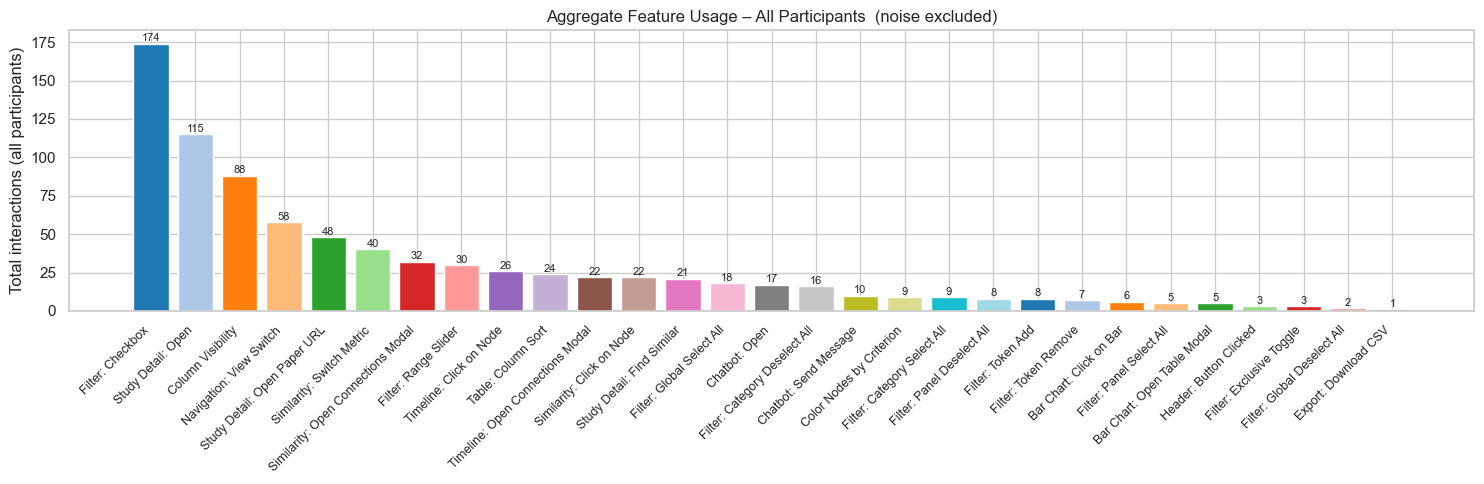

In [38]:
# ── Aggregate feature usage – bar chart ─────────────────────────────────────
# Exclude noise label from the main chart
agg_feat = feat_df.drop(columns=[NOISE_LABEL], errors="ignore").sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(15, 5))
colors = sns.color_palette("tab20", len(agg_feat))
bars = ax.bar(range(len(agg_feat)), agg_feat.values, color=colors)
ax.set_xticks(range(len(agg_feat)))
ax.set_xticklabels(agg_feat.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Total interactions (all participants)")
ax.set_title("Aggregate Feature Usage – All Participants  (noise excluded)")

for bar, val in zip(bars, agg_feat.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


Equal-Weighted View & Feature Usage



C:\Users\jonas\AppData\Local\Temp\ipykernel_5284\2782970842.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Figure saved to: C:\Users\jonas\Documents\Studium - PhD Informatik\Survey Paper Interaction\figs\user_study_logs.pdf


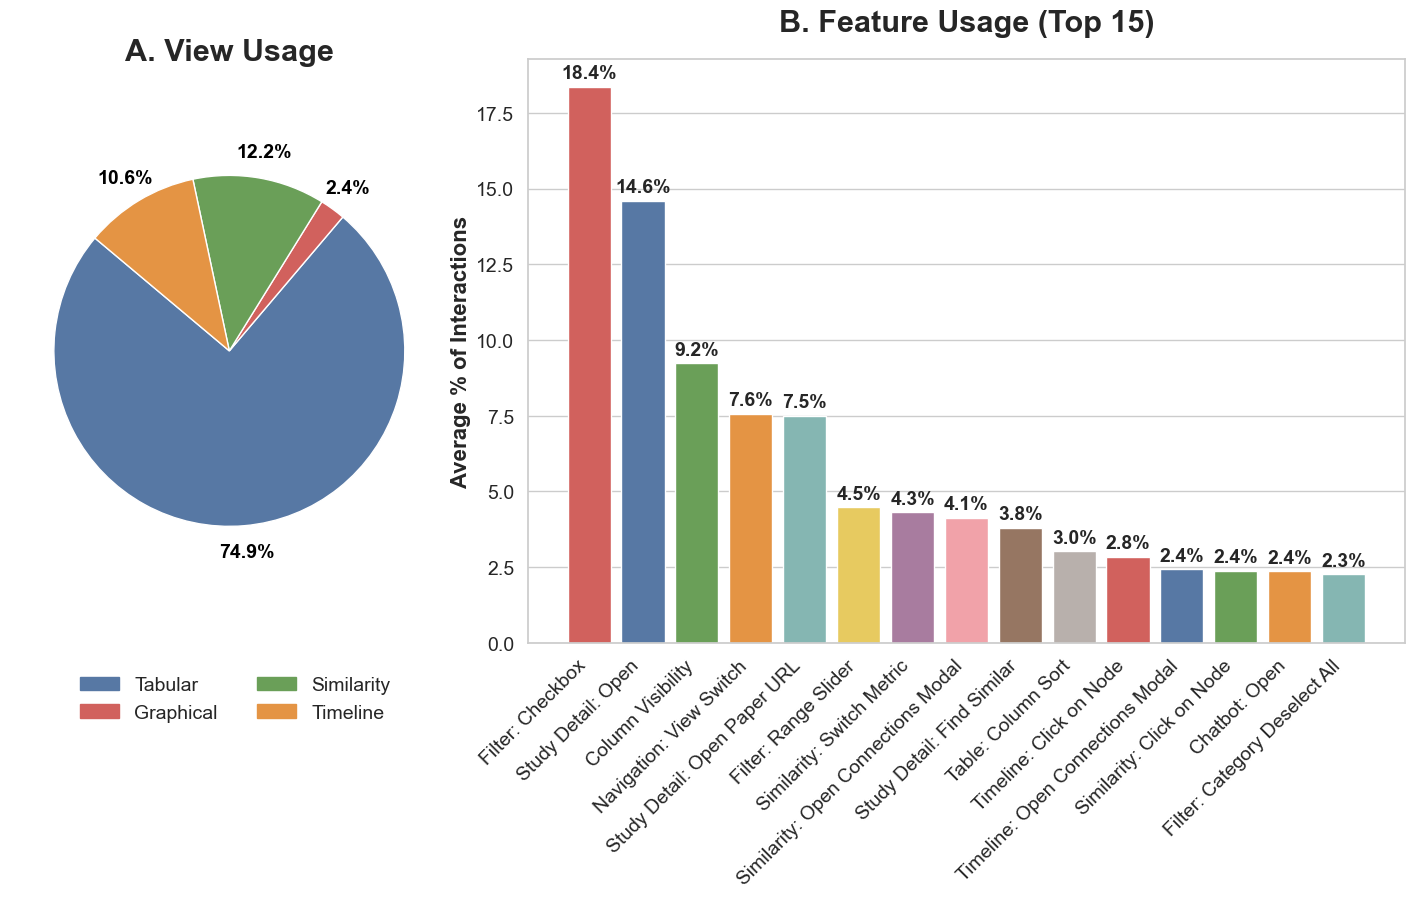

✓ Equal-weighted visualization created:
  - Views: Each participant normalized to 100%, then averaged
  - Features: Each participant normalized to 100%, then top 15 selected and averaged
  - Font sizes matched to publication standards (title: 22, labels: 16, ticks: 14)


In [ ]:
# Plot for Paper

print("\n" + "="*80)
print("Equal-Weighted View & Feature Usage")
print("="*80 + "\n")

custom_colors = [
 '#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2',
 '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac',
 '#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2',]

custom_colors_pie = [
 '#5778a4', '#d1615d', '#6a9f58', '#e49444', '#85b6b2',
 '#e7ca60', '#a87c9f', '#f1a2a9', '#967662', '#b8b0ac',
 '#d1615d', '#5778a4', '#6a9f58', '#e49444', '#85b6b2',]

# ── Configuration ────────────────────────────────────────────────────────────
N_FEATURES = 15  # Adjustable: number of top features to display

# ── Short names mapping for this plot ────────────────────────────────────────
VIEW_LABELS_SHORT = {
    "tableView":       "Tabular",
    "chartView":       "Graphical",
    "similarityView":  "Similarity",
    "timeView":        "Timeline",
}

# ── Recalculate view times per participant (used for equal-weight normalization) ─
view_rows_ew = []
for lg in logs:
    vt = compute_view_times(lg)
    row = {"Participant": lg["participant_id"]}
    for v in VIEW_ORDER:
        row[VIEW_LABELS_SHORT[v]] = round(vt[v] / 1000, 1)
    view_rows_ew.append(row)

view_df_ew = pd.DataFrame(view_rows_ew).set_index("Participant")

# ── Normalize to percentages per participant, then average ──────────────────
view_pct_per_person = view_df_ew.div(view_df_ew.sum(axis=1), axis=0) * 100
equal_weight_view = view_pct_per_person.mean()

# ── Recalculate feature counts per participant ────────────────────────────────
feature_rows_ew = []
for lg in logs:
    counts: dict[str, int] = {}
    for e in lg["events"]:
        f = classify_event(e)
        if f and f != NOISE_LABEL:  # Exclude infrastructure and noise
            counts[f] = counts.get(f, 0) + 1
    feature_rows_ew.append({"Participant": lg["participant_id"], **counts})

feat_df_ew = (
    pd.DataFrame(feature_rows_ew)
    .fillna(0)
    .set_index("Participant")
    .astype(int)
)

# ── Normalize to percentages per participant, then average ──────────────────
feat_pct_per_person = feat_df_ew.div(feat_df_ew.sum(axis=1), axis=0) * 100
equal_weight_feat = feat_pct_per_person.mean()

# Select top N features
top_features = equal_weight_feat.nlargest(N_FEATURES)

# ── Create figure with improved pie + feature bar layout ─────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 8))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 2], wspace=0.12, hspace=0.3)

# ── Left subplot: Pie chart (1/3 width, centered) ────────────────────────────
ax_pie = fig.add_subplot(gs[0, 0])
ax_pie.set_aspect('equal')
palette_pie = custom_colors_pie[:len(VIEW_ORDER)]
view_col_map_ew = dict(zip(equal_weight_view.index, palette_pie))

wedges, texts = ax_pie.pie(
    equal_weight_view,
    startangle=140,
    colors=[view_col_map_ew[c] for c in equal_weight_view.index],
)

# Add percentages outside the pie in black (closer to pie)
for wedge, value in zip(wedges, equal_weight_view.values):
    angle = np.radians((wedge.theta2 + wedge.theta1) / 2)
    x = 1.15 * np.cos(angle)
    y = 1.15 * np.sin(angle)
    ax_pie.text(x, y, f'{value:.1f}%', ha='center', va='center',
                fontsize=14, fontweight='bold', color='black')

ax_pie.set_title("A. View Usage", fontsize=22, fontweight="bold", pad=20)
ax_pie.set_ylim(-1.5, 1.5)  # Add space for legend below

# ── Right subplot: Feature bar chart (2/3 width) ────────────────────────────
ax_bar = fig.add_subplot(gs[0, 1:])
colors_feat = custom_colors[:len(top_features)]
bars = ax_bar.bar(range(len(top_features)), top_features.values, color=colors_feat)
ax_bar.grid(axis='y', linestyle='-')
ax_bar.grid(axis='x', visible=False)
ax_bar.set_xticks(range(len(top_features)))
ax_bar.set_xticklabels(top_features.index, rotation=45, ha="right", fontsize=14)
ax_bar.set_ylabel("Average % of Interactions", fontsize=16, fontweight="bold")
ax_bar.tick_params(axis="y", labelsize=14)
ax_bar.set_title(f"B. Feature Usage (Top {N_FEATURES})", 
                 fontsize=22, fontweight="bold", pad=20)

# Add value labels on bars
for bar, val in zip(bars, top_features.values):
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, height + 0.15,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=14, fontweight="bold")

# Add figure-level legend below in 2x2 grid (like reference notebook style)
handles = [plt.Rectangle((0, 0), 1, 1, color=palette_pie[i]) for i in range(len(VIEW_ORDER))]
labels = list(equal_weight_view.index)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.25, 0.13),
           ncol=2, fontsize=14, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for legend

# Save as PDF to same location as insights_statistics notebook
save_path = r"C:\Users\jonas\Documents\Studium - PhD Informatik\Survey Paper Interaction\figs\user_study_logs.pdf"
fig.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"✓ Figure saved to: {save_path}")

plt.show()

print(f"✓ Equal-weighted visualization created:")
print(f"  - Views: Each participant normalized to 100%, then averaged")
print(f"  - Features: Each participant normalized to 100%, then top {N_FEATURES} selected and averaged")
print(f"  - Font sizes matched to publication standards (title: 22, labels: 16, ticks: 14)")

In [44]:
# --- Accessibility listings for View Usage + Feature Usage figure ---

from datetime import datetime
from pathlib import Path

SAVE_MARKDOWN = True
ORDER_MODE = "descending"  # 'original', 'ascending', 'descending'

MARKDOWN_PATH = Path(
    r"C:\Users\jonas\Documents\Studium - PhD Informatik\Survey Paper Interaction\figs\view_feature_usage_listings.md"
)

def order_dict(d, mode="descending"):
    items = list(d.items())
    if mode == "descending":
        items = sorted(items, key=lambda x: x[1], reverse=True)
    elif mode == "ascending":
        items = sorted(items, key=lambda x: x[1])
    return items


# ---------------------------
# Build text output
# ---------------------------
lines = []
timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")

header = f"# View Usage & Feature Usage Listings\nGenerated {timestamp}\n"
print(header.strip())
lines.append(header)


# ---------------------------
# PIE: View usage
# ---------------------------
lines.append("\n# A. View Usage (Equal-weighted)\n")

view_items = order_dict(equal_weight_view.to_dict(), ORDER_MODE)

overall_view_line = "View Usage (overall %): " + ", ".join(
    [f'"{k}" = {v:.1f}%' for k, v in view_items]
)

print(overall_view_line)
lines.append(overall_view_line + "\n")


# ---------------------------
# BAR: Feature usage
# ---------------------------
lines.append("# B. Feature Usage (Top features, equal-weighted)\n")

feature_items = order_dict(top_features.to_dict(), ORDER_MODE)

feature_line = "Feature Usage (top features %): " + ", ".join(
    [f'"{k}" = {v:.1f}%' for k, v in feature_items]
)

print(feature_line)
lines.append(feature_line + "\n")


# ---------------------------
# Optional per-category structured view
# ---------------------------
lines.append("# Structured Breakdown\n")

print("\n# Structured Breakdown")

print("\nViews:")
for k, v in view_items:
    print(f"  - {k}: {v:.1f}%")
    lines.append(f"Views - {k}: {v:.1f}%")

print("\nFeatures:")
for k, v in feature_items:
    print(f"  - {k}: {v:.1f}%")
    lines.append(f"Features - {k}: {v:.1f}%")


# ---------------------------
# Save Markdown
# ---------------------------
if SAVE_MARKDOWN:
    MARKDOWN_PATH.parent.mkdir(parents=True, exist_ok=True)
    with MARKDOWN_PATH.open("w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")

    print(f"\nSaved listings to: {MARKDOWN_PATH}")

# View Usage & Feature Usage Listings
Generated 2026-06-25 07:45 UTC
View Usage (overall %): "Tabular" = 74.9%, "Similarity" = 12.2%, "Timeline" = 10.6%, "Graphical" = 2.4%
Feature Usage (top features %): "Filter: Checkbox" = 18.4%, "Study Detail: Open" = 14.6%, "Column Visibility" = 9.2%, "Navigation: View Switch" = 7.6%, "Study Detail: Open Paper URL" = 7.5%, "Filter: Range Slider" = 4.5%, "Similarity: Switch Metric" = 4.3%, "Similarity: Open Connections Modal" = 4.1%, "Study Detail: Find Similar" = 3.8%, "Table: Column Sort" = 3.0%, "Timeline: Click on Node" = 2.8%, "Timeline: Open Connections Modal" = 2.4%, "Similarity: Click on Node" = 2.4%, "Chatbot: Open" = 2.4%, "Filter: Category Deselect All" = 2.3%

# Structured Breakdown

Views:
  - Tabular: 74.9%
  - Similarity: 12.2%
  - Timeline: 10.6%
  - Graphical: 2.4%

Features:
  - Filter: Checkbox: 18.4%
  - Study Detail: Open: 14.6%
  - Column Visibility: 9.2%
  - Navigation: View Switch: 7.6%
  - Study Detail: Open Paper URL: 7.5%

C:\Users\jonas\AppData\Local\Temp\ipykernel_5284\4033372050.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")


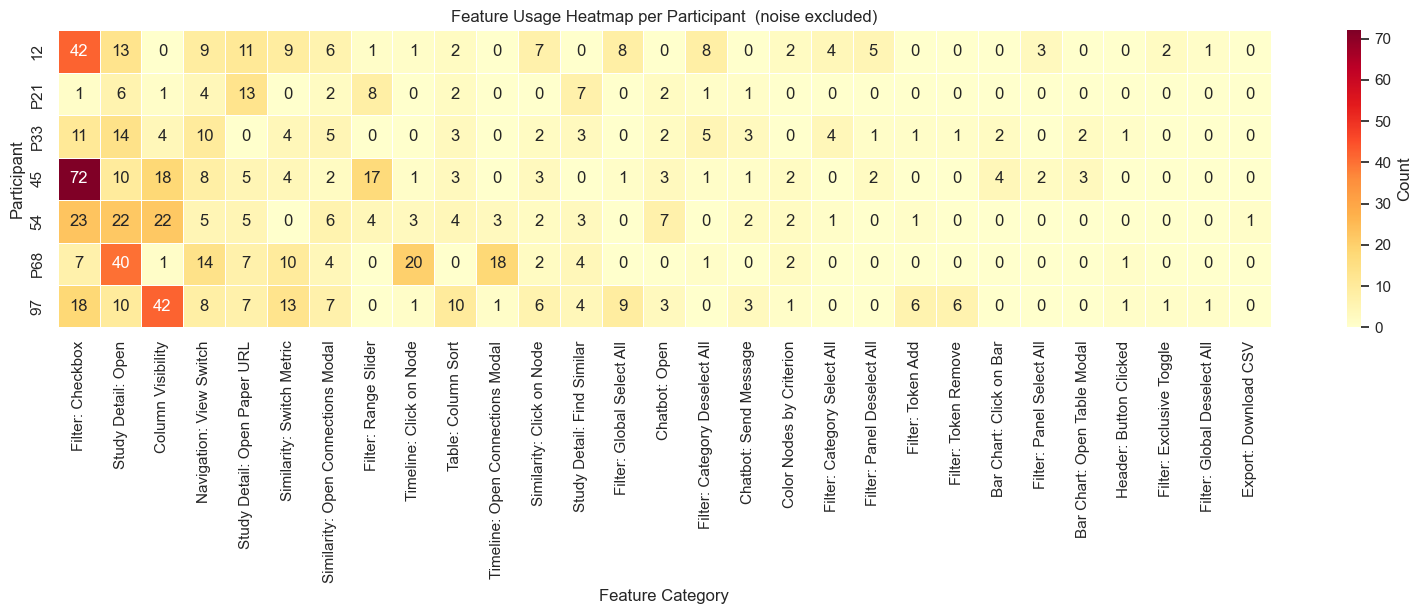

In [40]:
# ── Per-participant heatmap (only meaningful with ≥2 participants) ───────────
clean_feat_df = feat_df.drop(columns=[NOISE_LABEL], errors="ignore")

if len(logs) >= 2:
    fig, ax = plt.subplots(figsize=(16, max(4, len(logs) * 0.9)))
    sns.heatmap(clean_feat_df, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Count"})
    ax.set_title("Feature Usage Heatmap per Participant  (noise excluded)")
    ax.set_xlabel("Feature Category")
    ax.set_ylabel("Participant")
    plt.tight_layout()
    plt.show()
else:
    print("Only one participant in the dataset – heatmap omitted.")

## 6 · Detailed Filter Analysis

Which **specific filter columns** did participants interact with most?

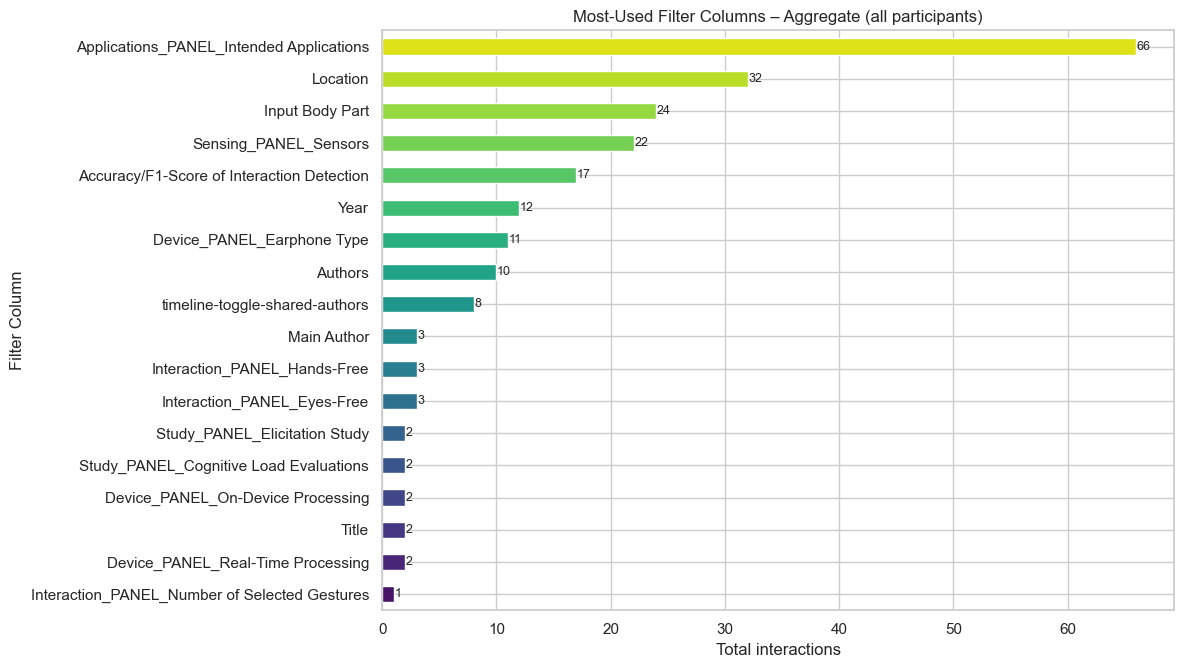

Filter Column,Accuracy/F1-Score of Interaction Detection,Applications_PANEL_Intended Applications,Authors,Device_PANEL_Earphone Type,Device_PANEL_On-Device Processing,Device_PANEL_Real-Time Processing,Input Body Part,Interaction_PANEL_Eyes-Free,Interaction_PANEL_Hands-Free,Interaction_PANEL_Number of Selected Gestures,Location,Main Author,Sensing_PANEL_Sensors,Study_PANEL_Cognitive Load Evaluations,Study_PANEL_Elicitation Study,Title,Year,timeline-toggle-shared-authors
Participant,,,,,,,,,,,,,,,,,,
12,0,5,0,8,0,0,2,3,3,0,13,0,4,0,0,0,1,6
45,16,58,0,0,0,0,4,0,0,0,6,0,0,2,2,0,1,0
54,1,0,0,0,0,0,12,0,0,1,11,1,0,0,0,0,2,0
97,0,0,10,3,2,2,0,0,0,0,0,2,12,0,0,0,0,0
P21,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,0
P33,0,3,0,0,0,0,6,0,0,0,2,0,0,0,0,2,0,0
P68,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,2


In [42]:
FILTER_EVENT_TYPES = {
    "filter_checkbox_toggled",
    "range_filter_moved",
    "token_filter_added",
    "token_filter_removed",
    "exclusive_filter_toggled",
}

filter_col_records = []
for lg in logs:
    pid = lg["participant_id"]
    for e in lg["events"]:
        col = e.get("col")
        if col and e["type"] in FILTER_EVENT_TYPES:
            filter_col_records.append({
                "Participant":    pid,
                "Filter Column":  col,
                "Event Type":     e["type"],
                "View":           VIEW_LABELS.get(e.get("view", ""), e.get("view", "")),
            })

if filter_col_records:
    fc_df = pd.DataFrame(filter_col_records)

    # Aggregate: total interactions per filter column
    agg_fc = (
        fc_df.groupby("Filter Column")
        .size()
        .sort_values(ascending=True)
        .rename("Total Interactions")
    )

    fig, ax = plt.subplots(figsize=(12, max(4, len(agg_fc) * 0.38)))
    agg_fc.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(agg_fc)))
    ax.set_title("Most-Used Filter Columns – Aggregate (all participants)")
    ax.set_xlabel("Total interactions")
    for i, v in enumerate(agg_fc.values):
        ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Per-participant breakdown
    per_p = (
        fc_df.groupby(["Participant", "Filter Column"])
        .size()
        .unstack(fill_value=0)
    )
    display(per_p.style.background_gradient(cmap="YlOrRd", axis=None))
else:
    print("No filter-column data found in the loaded logs.")